# Script for Processing floats with PAR and Chlorophyll #

## apply methods to understand iron stress in other locations than the southern ocean ##
## Is there a signal and signal differece? ##
## What is happening in those different regions? ##

### My task: process PAR data and find when it = 15 ###

In [59]:
print("hello")

hello


In [60]:
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

import matplotlib.pyplot as plt
from cmocean import cm as cmo
from cartopy import crs as ccrs
import xarray as xr

from scipy.stats import iqr
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [61]:
# set the float file 

proj_directory = '/home/jovyan/SO_iron_project/'
float_file = '1902593_Sprof_BGCArgoPlus.nc'

In [62]:
argo_n = xr.open_dataset(proj_directory + float_file) 
argo_n

<xarray.Dataset> Size: 65MB
Dimensions:                                            (N_PROF: 73,
                                                        N_PARAM: 15,
                                                        N_CALIB: 1,
                                                        N_LEVELS: 1499)
Coordinates:
    JULD                                               (N_PROF) datetime64[ns] 584B ...
    LATITUDE                                           (N_PROF) float64 584B ...
    LONGITUDE                                          (N_PROF) float64 584B ...
    PRES_ADJUSTED_BGCArgoPlus                          (N_PROF, N_LEVELS) float32 438kB ...
  * N_LEVELS                                           (N_LEVELS) int64 12kB ...
  * N_PROF                                             (N_PROF) int64 584B 0 ...
Dimensions without coordinates: N_PARAM, N_CALIB
Data variables: (12/189)
    DATA_TYPE                                          object 8B ...
    FORMAT_VERSION                                     object 8B ...
    HANDBOOK_VERSION                                   object 8B ...
    REFERENCE_DATE_TIME                                object 8B ...
    DATE_CREATION                                      object 8B ...
    DATE_UPDATE                                        object 8B ...
    ...                                                 ...
    spiciness0                                         (N_PROF, N_LEVELS) float64 875kB ...
    cons_temp                                          (N_PROF, N_LEVELS) float64 875kB ...
    gamma                                              (N_PROF, N_LEVELS) float64 875kB ...
    depth                                              (N_PROF, N_LEVELS) float64 875kB ...
    MLD                                                (N_PROF) float64 584B ...
    DOXY_SAT                                           (N_PROF, N_LEVELS) float64 875kB ...
Attributes:
    title:                Argo float vertical profile
    institution:          CORIOLIS
    source:               Argo float
    history:              2024-12-21T07:11:50Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

In [63]:
print(argo_n.dims)

FrozenMappingWarningOnValuesAccess({'N_PROF': 73, 'N_PARAM': 15, 'N_CALIB': 1, 'N_LEVELS': 1499})


Text(0.5, 1.0, 'Float 1902593 Track')

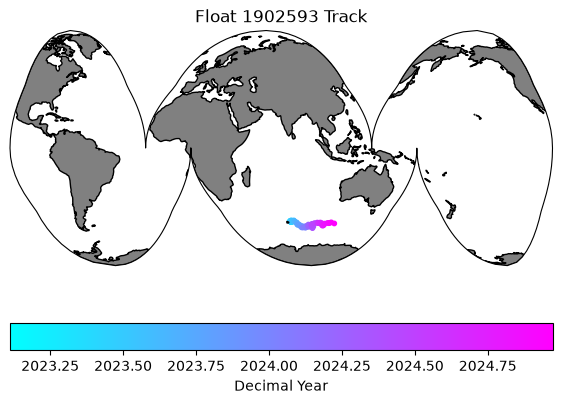

In [64]:
# First let's make a map of the figure track so we know where it is: 

# For plotting it will be easier if we create a time variable in decimal years
argo_n['decimal_year'] = (['N_PROF'],np.empty(argo_n.PRES_ADJUSTED.shape[0])) # add an empty variable 
argo_n.decimal_year[:] = np.nan # set all values to nan
date_time = pd.to_datetime(argo_n.JULD.values) # get out the time, converted to a Pandas datetime
year = date_time.year # extract the year
decimal_year = year + (date_time.day_of_year - 1) / 365.25 # extract the day of year, convert to decimal year and add the year
argo_n.decimal_year[:] = decimal_year # save into the array. This step isn't really necessary here, but keeps things organized and you could save it out for later use. I should probably just add decimal year to the files..

data_proj = ccrs.PlateCarree(central_longitude=0)
map_proj =ccrs.InterruptedGoodeHomolosine(central_longitude=argo_n['LONGITUDE'][0].values, globe=None, emphasis='ocean')

fig = plt.figure(figsize=(7,5))

ax0 = fig.add_subplot(1,1,1, projection=map_proj)
ax0.set_global()
ax0.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))

map = ax0.scatter(argo_n.LONGITUDE.values, argo_n.LATITUDE.values, s=10, c=argo_n.decimal_year, transform=data_proj, cmap='cool')
plt.colorbar(map, label='Decimal Year', orientation='horizontal')
plt.title('Float ' + str(argo_n['WMO_ID'].values) + ' Track')


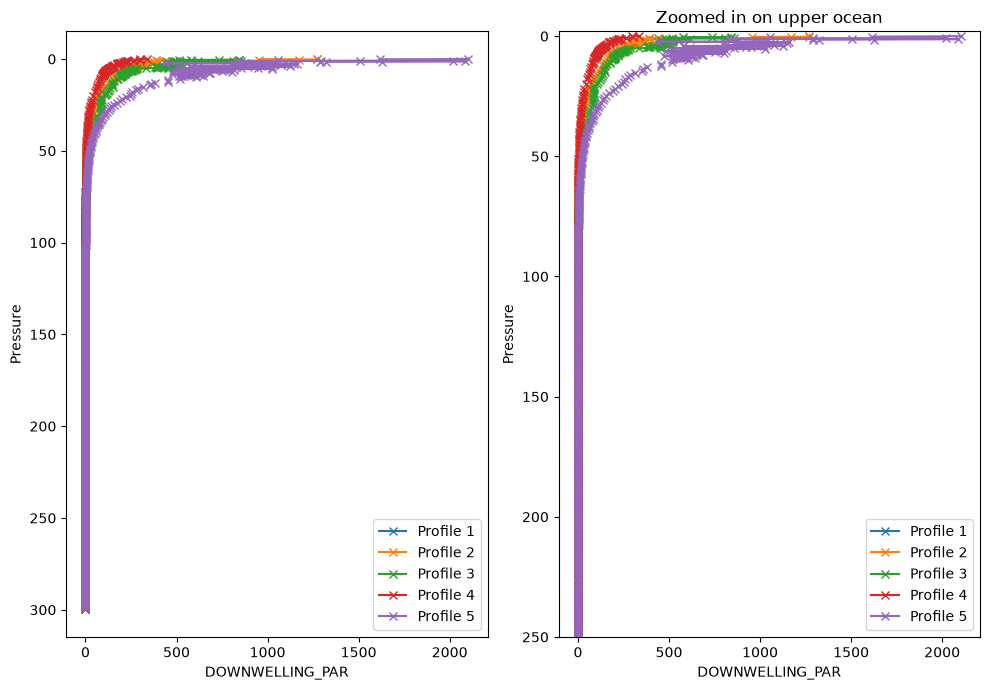

In [65]:
# make a plot of the first few profiles of PAR 
var_choice = 'DOWNWELLING_PAR'

fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# We can plot the first X profiles to get a look at the data:
profiles = range(5)

for p in profiles:
    ax1.plot(argo_n[var_choice][p, :], argo_n['PRES'][p, :], marker='x', label=f'Profile {p+1}')
    ax2.plot(argo_n[var_choice][p, :], argo_n['PRES'][p, :], marker='x', label=f'Profile {p+1}')
ax1.invert_yaxis()
ax1.set_xlabel(var_choice)
ax1.set_ylabel('Pressure')
ax1.legend()
#ax1.set_title(f'Float {argo_n['WMO_ID'].values}, First {profiles} Profiles')
# our second axis is zoomed in to the upper 250m
ax2.invert_yaxis()
ax2.set_xlabel(var_choice)
ax2.set_ylabel('Pressure')
ax2.legend()
ax2.set_title('Zoomed in on upper ocean')
max_pres = 250
ax2.set_ylim(max_pres, -2)
plt.tight_layout()

# units of PAR: microMoleQuanta/m^2/sec
 

In [132]:

# code to find par = 15 
def par15(argo_n):
    
    
    par15_pressure = np.full(argo_n.sizes['N_PROF'], np.nan)
    profiles = range(argo_n.sizes['N_PROF']) # define profile range 

    for p in profiles:

        par = argo_n['DOWNWELLING_PAR'][p,:].values # make 
        pres = argo_n['PRES_ADJUSTED'][p,:].values
    
        par_value_check = par >= 13
        par = par[par_value_check]
        pres = pres[par_value_check] # check that par is not small or 0 or weird messy number 
    
        valid = np.isfinite(par) & np.isfinite(pres) # Check same length. 
        #print(valid)


        par = par[valid]
        

        press = pres[valid] # make sure they are the same size 
        
        
        if len(par) == 0:
            continue # if 0, move on 

        find_par_15 = np.abs(par - 15).argmin()
        
        # Save pressure
        par15_pressure[p] = press[find_par_15]

    # Add result to dataset
    argo_n['par_15_pressure'] = (['N_PROF'], par15_pressure)

    return argo_n


In [133]:
argo_n = par15(argo_n)

In [134]:
argo_n

<xarray.Dataset> Size: 65MB
Dimensions:                                            (N_PROF: 73,
                                                        N_PARAM: 15,
                                                        N_CALIB: 1,
                                                        N_LEVELS: 1499)
Coordinates:
    JULD                                               (N_PROF) datetime64[ns] 584B ...
    LATITUDE                                           (N_PROF) float64 584B ...
    LONGITUDE                                          (N_PROF) float64 584B ...
    PRES_ADJUSTED_BGCArgoPlus                          (N_PROF, N_LEVELS) float32 438kB ...
  * N_LEVELS                                           (N_LEVELS) int64 12kB ...
  * N_PROF                                             (N_PROF) int64 584B 0 ...
Dimensions without coordinates: N_PARAM, N_CALIB
Data variables: (12/191)
    DATA_TYPE                                          object 8B ...
    FORMAT_VERSION                                     object 8B ...
    HANDBOOK_VERSION                                   object 8B ...
    REFERENCE_DATE_TIME                                object 8B ...
    DATE_CREATION                                      object 8B ...
    DATE_UPDATE                                        object 8B ...
    ...                                                 ...
    gamma                                              (N_PROF, N_LEVELS) float64 875kB ...
    depth                                              (N_PROF, N_LEVELS) float64 875kB ...
    MLD                                                (N_PROF) float64 584B ...
    DOXY_SAT                                           (N_PROF, N_LEVELS) float64 875kB ...
    decimal_year                                       (N_PROF) float64 584B ...
    par_15_pressure                                    (N_PROF) float64 584B ...
Attributes:
    title:                Argo float vertical profile
    institution:          CORIOLIS
    source:               Argo float
    history:              2024-12-21T07:11:50Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182